# EDA - Data Exploration

Exploratory Data Analysis notebook for the DFL AWS Hackathon Challenge 2 dataset.

**Goals:**
1. Inventory the S3 bucket and understand available data files
2. Inspect the match metadata JSON (game ID, frame ranges, team rosters)
3. Parse the MatchInformation XML to understand the data schema
4. Sample the skeleton Parquet file and validate the schema
5. Run an end-to-end AWI smoke test on a single player (Kimmich, FCB-HSV Phase 1)

**Data source:** S3 bucket `your-s3-bucket-name`  
**Match used for smoke test:** FC Bayern München vs Hamburger SV, 2025-09-13

## Cell 0. Imports and AWS Session Setup

Imports required libraries and creates an authenticated AWS session using the profile and region from environment variables.

In [1]:
# Cell 0: Imports and AWS session setup
# Requirements: 2.1, 2.2, 2.3

import sys, os
sys.path.insert(0, os.path.abspath(".."))

import boto3
import json
import xml.etree.ElementTree as ET
import pyarrow
import pyarrow.parquet as pq
import pyarrow.fs as pafs
import os
import pandas as pd

from src.eda_helpers import (
    create_session,
    list_bucket,
    load_json,
    load_xml,
    sample_parquet,
    report_dataframe,
    report_dict,
    report_xml,
)

# Constants
SESSION_PROFILE = os.environ.get("AWS_PROFILE")
REGION = "eu-central-1"
BUCKET = os.environ.get("HACKATHON_BUCKET")
CHALLENGE_PREFIX = "Challenge 2 – Unlock the Power of 3D Football Data/Match_Data"

METADATA_KEY = f"{CHALLENGE_PREFIX}/Bayern_Hamburg/2025_09_13_FCB_HSV/2025-09-13_FCB-HSV_metadata.json"
MATCH_INFO_KEY = f"{CHALLENGE_PREFIX}/Bayern_Hamburg/MatchInformations_Bayern_Hamburg.xml"
PARQUET_PATH = f"{BUCKET}/{CHALLENGE_PREFIX}/Bayern_Hamburg/FCB-HSV.parquet"

# Create AWS session
try:
    session, s3_client, s3fs = create_session(SESSION_PROFILE, REGION)
    if session is not None:
        print(f"[OK] AWS session created successfully (profile={SESSION_PROFILE}, region={REGION})")
    else:
        print(f"[ERROR] Failed to create AWS session for profile '{SESSION_PROFILE}'")
except Exception as e:
    print(f"[ERROR] Unexpected error creating AWS session: {e}")

[OK] AWS session created successfully (profile=707421297703_slalom_IsbUsersPS, region=eu-central-1)


## Cell 1. List S3 Bucket Contents

Lists all objects in the hackathon S3 bucket with their sizes.  
Provides an overview of available match data files (Parquet, XML, JSON) across all 5 matches.

In [2]:
# Cell 1: List S3 bucket contents
# Requirements: 1.1, 1.2, 1.3

objects = list_bucket(s3_client, BUCKET)
print(f"Total objects in s3://{BUCKET}: {len(objects)}\n")
print(f"{'Key':<80} | {'Size (bytes)':>15}")
print("-" * 98)
for obj in objects:
    print(f"{obj['Key']:<80} | {obj['Size']:>15}")

Total objects in s3://hackathon-data-707421297703: 108

Key                                                                              |    Size (bytes)
--------------------------------------------------------------------------------------------------
Challenge 2 – Unlock the Power of 3D Football Data/Documentation/Challenge 2 – Unlock the Power of 3D Football Data.pdf |          113760
Challenge 2 – Unlock the Power of 3D Football Data/Documentation/Documentation_EvenData.pdf |          410363
Challenge 2 – Unlock the Power of 3D Football Data/Documentation/Documentation_KPI_Data.pdf |         1058857
Challenge 2 – Unlock the Power of 3D Football Data/Documentation/Documentation_MatchInformation.pdf |         2310408
Challenge 2 – Unlock the Power of 3D Football Data/Documentation/Documentation_PositinalData.pdf |          401021
Challenge 2 – Unlock the Power of 3D Football Data/Documentation/Documentation_SkeletonData.pdf |          807199
Challenge 2 – Unlock the Power of 3D Foot

## Cell 2. Load and Inspect Metadata JSON

Loads the match metadata JSON for FCB-HSV and prints a structured summary.  
Key fields: game ID, frame rate, pitch dimensions, phase frame ranges, and team rosters.

In [3]:
# Cell 2: Load and report metadata.json
# Requirements: 3.1, 3.2, 3.3, 3.4

metadata = load_json(s3_client, BUCKET, METADATA_KEY)
if metadata is not None:
    report_dict("Metadata JSON", metadata)
else:
    print(f"[ERROR] Could not load metadata from s3://{BUCKET}/{METADATA_KEY}")


Metadata JSON
  GameID: int = 189024
  CompetitionID: int = 51
  SeasonID: int = 2025
  FrameRate: int = 50
  PitchShortSide: int = 6800
  PitchLongSide: int = 10500
  Phase1StartFrame: int = 3330853
  Phase1EndFrame: int = 3483888
  Phase2StartFrame: int = 3536383
  Phase2EndFrame: int = 3677312
  Phase3StartFrame: int = 0
  Phase3EndFrame: int = 0
  Phase4StartFrame: int = 0
  Phase4EndFrame: int = 0
  Phase5StartFrame: int = 0
  Phase5EndFrame: int = 0
  Phase1HomeGKLeft: bool = False
  Phase2HomeGKLeft: bool = True
  Phase3HomeGKLeft: NoneType = None
  Phase4HomeGKLeft: NoneType = None
  Phase5HomeGKLeft: NoneType = None
  HomeTeam: dict = {'LongName': 'FC Bayern München', 'ShortName': 'FC Bayern München', 'TeamID': 10, 'Players': [{'PlayerID': 28359, 'FirstName': 'Manuel Peter', 'LastName': 'Neuer', 'JerseyNo': 1, 'StartFrameCount': 3330853, 'EndFrameCount': 3677312, 'StartingPosition': 'G', 'CurrentPosition': 'G'}, {'PlayerID': 33669, 'FirstName': 'Sven', 'LastName': 'Ulreich', 

In [4]:
import s3fs, os
fs = s3fs.S3FileSystem(profile=os.environ["AWS_PROFILE"])
fs.ls(f"s3://{BUCKET}/{CHALLENGE_PREFIX}")


['hackathon-data-707421297703/Challenge 2 – Unlock the Power of 3D Football Data/Match_Data/Bayern_Hamburg',
 'hackathon-data-707421297703/Challenge 2 – Unlock the Power of 3D Football Data/Match_Data/Dortmund_Stuttgart',
 'hackathon-data-707421297703/Challenge 2 – Unlock the Power of 3D Football Data/Match_Data/Frankfurt_Bayern',
 'hackathon-data-707421297703/Challenge 2 – Unlock the Power of 3D Football Data/Match_Data/Frankfurt_Union',
 'hackathon-data-707421297703/Challenge 2 – Unlock the Power of 3D Football Data/Match_Data/Union_Bayern']

## Cell 3. Parse MatchInformation XML

Loads and parses the MatchInformations XML file for FCB-HSV.  
Reports the root tag, attributes, and child structure to understand the DFL XML schema.

In [5]:
# Cell 3: Parse and report MatchInformations XML
# Requirements: 4.1, 4.2, 4.3, 4.4, 4.5

root = load_xml(s3_client, BUCKET, MATCH_INFO_KEY)
if root is not None:
    report_xml("MatchInformation XML", root)
else:
    print(f"[ERROR] Could not load XML from s3://{BUCKET}/{MATCH_INFO_KEY}")


MatchInformation XML
Root tag: PutDataRequest
Root attributes: {'RequestId': '849958d9-7883-4661-bcfc-032c06b286d0', 'MessageTime': '2025-12-13T05:39:58.920+00:00', 'TransmissionComplete': 'true', 'TransmissionSuspended': 'false'}
Child tags: ['MatchInformation']
Child count: 1


## Cell 4. Sample Skeleton Parquet and Inspect Schema

Reads the PyArrow schema from the FCB-HSV Parquet file (schema-only, no full data load) and samples the first 10,000 rows.  
Validates the nested skeleton struct format: `frame_number`, `ball`, `skeletons` (list of `jersey_number`, `team`, `parts`).

In [6]:
# Cell 4: Sample FCB-HSV.parquet and report schema + shape
# Requirements: 5.1, 5.2, 5.3, 5.4, 6.1, 6.2, 6.3, 6.4

# Read pyarrow schema separately (schema-only, no full data load)
# Guard against name shadowing (e.g., `import s3fs` turning `s3fs` into a module)
pa_fs = s3fs if isinstance(s3fs, pafs.FileSystem) else pafs.S3FileSystem(region=REGION)

# Normalize Parquet path for pyarrow (expects bucket/key when filesystem is provided)
parquet_path = PARQUET_PATH.replace("s3://", "").lstrip("/")

try:
    pq_file = pq.ParquetFile(parquet_path, filesystem=pa_fs)
except Exception:
    # Fallback for SSO / temporary-credential issues with pyarrow S3FileSystem
    if session is None:
        raise RuntimeError("AWS session is not available for S3 credential fallback.")

    creds = session.get_credentials()
    if creds is None:
        raise RuntimeError("No AWS credentials available from boto3 session.")

    frozen = creds.get_frozen_credentials()
    if not frozen.access_key or not frozen.secret_key:
        raise RuntimeError("Incomplete AWS credentials for pyarrow S3 fallback.")

    pa_fs = pafs.S3FileSystem(
        region=REGION,
        access_key=frozen.access_key,
        secret_key=frozen.secret_key,
        session_token=frozen.token,
    )
    pq_file = pq.ParquetFile(parquet_path, filesystem=pa_fs)

# Keep downstream helper calls working in this notebook cell
s3fs = pa_fs
pq_schema = pq_file.schema_arrow

# Sample first 10,000 rows
df = sample_parquet(s3fs, PARQUET_PATH)

if df is not None:
    report_dataframe("SkeletonData Parquet", df, schema=pq_schema)
else:
    print(f"[ERROR] Could not sample parquet at {PARQUET_PATH}")


SkeletonData Parquet
Parquet schema:
 ball: struct<position_x: float not null, position_y: float not null, position_z: float not null, velocity_ (... 74 chars omitted)
  child 0, position_x: float not null
  child 1, position_y: float not null
  child 2, position_z: float not null
  child 3, velocity_x: float not null
  child 4, velocity_y: float not null
  child 5, velocity_z: float not null
ball_exists: bool not null
frame_number: int32 not null
skeleton_count: int8 not null
skeletons: list<element: struct<jersey_number: int8 not null, parts: list<element: struct<name: int8 not null,  (... 162 chars omitted) not null
  child 0, element: struct<jersey_number: int8 not null, parts: list<element: struct<name: int8 not null, position_x: fl (... 138 chars omitted) not null
      child 0, jersey_number: int8 not null
      child 1, parts: list<element: struct<name: int8 not null, position_x: float not null, position_y: float not null, po (... 35 chars omitted) not null
          child 0, 

## AWI Pipeline – End-to-End Smoke Test

**Goal:** Validate the full pipeline on real S3 data before scaling to all 5 matches.

**Approach:**
1. Inspect raw skeleton struct from the already-sampled `df` (Cell 4) – confirm parsing assumptions
2. Load Phase 1 of FCB-HSV in batches via pyarrow filters (memory-efficient)
3. Run `extract_head_angles` → `detect_scans` → `compute_awi` for **Kimmich (Jersey 6, Home)**
4. Sanity-check the result with a head-yaw time series plot

**Match:** FC Bayern München vs Hamburger SV, 2025-09-13  
**Phase 1 frames:** 3 330 943 – 3 484 329 (~51 min, 50 fps)

In [7]:
# Cell 5: Validate skeleton parsing on real data (uses df from Cell 4)

from src.skeleton_parser import PART, _parts_to_dict, _head_yaw_from_nose_neck, _head_yaw_from_ears

# Phase 1 frame range (from parquet metadata)
PHASE1_START = 3_330_943
PHASE1_END   = 3_484_329
FRAMERATE    = 50

# Target player for smoke test
KIMMICH_JERSEY = 6
KIMMICH_TEAM   = 1  # Home

# ── Step 1: Confirm struct format on the existing 10k-row sample ──────────
print("=== Skeleton struct inspection ===\n")

found_kimmich = False
for _, row in df.iterrows():
    for skeleton in row["skeletons"]:
        if skeleton["jersey_number"] == KIMMICH_JERSEY and skeleton["team"] == KIMMICH_TEAM:
            print(f"Frame {row['frame_number']}: found Jersey={skeleton['jersey_number']} Team={skeleton['team']}")
            print(f"  parts_count : {skeleton['parts_count']}")
            print(f"  parts type  : {type(skeleton['parts'])}")
            print(f"  first part  : {skeleton['parts'][0]}")

            # Try to compute head yaw
            parts_dict = _parts_to_dict(skeleton["parts"])
            yaw_nn  = _head_yaw_from_nose_neck(parts_dict)
            yaw_ear = _head_yaw_from_ears(parts_dict)
            print(f"  head yaw (nose/neck) : {yaw_nn}")
            print(f"  head yaw (ears)      : {yaw_ear}")

            available_ids = sorted(parts_dict.keys())
            id_to_name = {v: k for k, v in PART.items()}
            print(f"  head parts available : {[id_to_name.get(i, i) for i in available_ids]}")
            found_kimmich = True
            break
    if found_kimmich:
        break

if not found_kimmich:
    # The 10k sample starts at frame 3_294_944 (pre-kickoff warmup)
    # Kimmich's StartFrameCount is 3_330_853 so he may not appear yet
    print("[INFO] Kimmich not found in the 10k sample (pre-kickoff frames).")
    print("       This is expected – sample starts before Phase 1.")
    print("       Showing the first skeleton found instead:")
    first_row = df[df["skeleton_count"] > 0].iloc[0]
    first_skel = first_row["skeletons"][0]
    print(f"  Frame {first_row['frame_number']}: Jersey={first_skel['jersey_number']} Team={first_skel['team']}")
    print(f"  parts type  : {type(first_skel['parts'])}")
    print(f"  first part  : {first_skel['parts'][0]}")
    parts_dict = _parts_to_dict(first_skel["parts"])
    yaw_nn  = _head_yaw_from_nose_neck(parts_dict)
    yaw_ear = _head_yaw_from_ears(parts_dict)
    print(f"  head yaw (nose/neck) : {yaw_nn}")
    print(f"  head yaw (ears)      : {yaw_ear}")

print("\n[OK] Struct format validated – parser assumptions confirmed.")

=== Skeleton struct inspection ===

[INFO] Kimmich not found in the 10k sample (pre-kickoff frames).
       This is expected – sample starts before Phase 1.
       Showing the first skeleton found instead:
  Frame 3294944: Jersey=-1 Team=-1
  parts type  : <class 'numpy.ndarray'>
  first part  : {'name': 16, 'position_x': -19.716299057006836, 'position_y': -12.468299865722656, 'position_z': 0.002099999925121665}
  head yaw (nose/neck) : -47.47180694971714
  head yaw (ears)      : -50.46049483930573

[OK] Struct format validated – parser assumptions confirmed.


In [8]:
# Cell 6: Batch AWI pipeline – stream Phase 1 from S3 efficiently
#
# Fix: ParquetFile.iter_batches() does not support 'filters' in all pyarrow versions.
# Solution: use pq.read_table() with filters (supported since pyarrow 1.0),
# then iterate over the in-memory table in chunks.
#
# Phase 1 is ~153k frames. At ~6 columns of mixed types that's roughly 150–300 MB
# in memory – well within typical limits.

import pyarrow.parquet as pq
import pandas as pd
import time

from src.skeleton_parser import extract_head_angles
from src.awi_calculator import detect_scans, compute_awi

BATCH_SIZE = 30_000  # rows per Python iteration (~10 min of match time)

def load_player_head_angles_phase(
    s3fs,
    parquet_path: str,
    jersey_number: int,
    team: int,
    phase_start: int,
    phase_end: int,
    batch_size: int = BATCH_SIZE,
) -> pd.DataFrame:
    """Stream a Parquet file in batches, extract head yaw for one player.

    Uses pq.read_table() with row-level filters so only Phase 1 row groups
    are transferred from S3, then iterates the result in Python-side chunks.

    Args:
        s3fs:         pyarrow S3FileSystem
        parquet_path: S3 path without s3:// prefix (bucket/key)
        jersey_number, team: player identifier
        phase_start, phase_end: frame number boundaries (inclusive)
        batch_size:   rows per Python-side iteration (does not affect S3 transfer)

    Returns:
        DataFrame[frame_number, head_yaw_deg] for the full phase.
    """
    filters = [
        ("frame_number", ">=", phase_start),
        ("frame_number", "<=", phase_end),
    ]

    print(f"  Downloading Phase 1 rows from S3 (filters applied at row-group level)...")
    t_dl = time.time()
    table = pq.read_table(parquet_path, filesystem=s3fs, filters=filters)
    print(f"  Downloaded {len(table):,} rows in {time.time()-t_dl:.1f}s")

    chunks = []
    t0 = time.time()

    for start in range(0, len(table), batch_size):
        df_chunk = table.slice(start, batch_size).to_pandas()
        chunk_angles = extract_head_angles(df_chunk, jersey_number, team)
        if not chunk_angles.empty:
            chunks.append(chunk_angles)

        processed = min(start + batch_size, len(table))
        print(
            f"  parsed {processed:>7,} / {len(table):,} frames | "
            f"angles: {sum(len(c) for c in chunks):>6,} | "
            f"{time.time()-t0:.1f}s",
            end="\r",
        )

    print()
    if not chunks:
        return pd.DataFrame(columns=["frame_number", "head_yaw_deg"])

    return (
        pd.concat(chunks, ignore_index=True)
        .sort_values("frame_number")
        .reset_index(drop=True)
    )


print(f"Loading Phase 1 head angles for Kimmich (Jersey={KIMMICH_JERSEY}, Team={KIMMICH_TEAM})")
print(f"  Frames {PHASE1_START:,} – {PHASE1_END:,}  |  batch_size={BATCH_SIZE:,}")
print()

t_start = time.time()
kimmich_angles = load_player_head_angles_phase(
    s3fs,
    PARQUET_PATH,
    jersey_number=KIMMICH_JERSEY,
    team=KIMMICH_TEAM,
    phase_start=PHASE1_START,
    phase_end=PHASE1_END,
    batch_size=BATCH_SIZE,
)
t_total = time.time() - t_start

print(f"\n[OK] Done in {t_total:.1f}s")
print(f"     Frames with valid head angle : {len(kimmich_angles):,}")
print(f"     Coverage                     : "
      f"{len(kimmich_angles) / (PHASE1_END - PHASE1_START) * 100:.1f}%")
print()
print("Sample head angles (first 10 rows):")
print(kimmich_angles.head(10).to_string(index=False))

Loading Phase 1 head angles for Kimmich (Jersey=6, Team=1)
  Frames 3,330,943 – 3,484,329  |  batch_size=30,000

  Downloaded 153,387 rows in 82.3s
  parsed 153,387 / 153,387 frames | angles: 148,991 | 64.6s

[OK] Done in 147.0s
     Frames with valid head angle : 148,991
     Coverage                     : 97.1%

Sample head angles (first 10 rows):
 frame_number  head_yaw_deg
      3330943    -99.894906
      3330944    -97.497043
      3330945    -95.761235
      3330946    -94.375783
      3330947    -93.822915
      3330948    -93.414759
      3330949    -93.297629
      3330950    -93.700820
      3330951    -93.990835
      3330952    -94.292779


In [9]:
# Cell 7a: Raw yaw signal inspection
#
# Uses kimmich_angles from Cell 6 (no S3 needed).
# Shows raw yaw values over 30 consecutive frames to diagnose signal quality:
#   - std <= 60 degrees = stable, smoothing will work
#   - std >  60 degrees = noisy, tracking outliers dominate

import numpy as np

if len(kimmich_angles) == 0:
    print("WARNING: kimmich_angles is empty. Run Cell 6 first.")
else:
    sample = kimmich_angles.head(30)
    yaws   = sample["head_yaw_deg"].values
    frames = sample["frame_number"].values

    print(f"Total frames extracted : {len(kimmich_angles):,}")
    print(f"Coverage               : {len(kimmich_angles)/(PHASE1_END-PHASE1_START)*100:.1f}%")
    print()
    print("Raw head yaw - first 30 frames:")
    print(f"{'Frame':>10}  {'Yaw (deg)':>10}  {'Frame-delta':>12}")
    prev = None
    for frame, yaw in zip(frames, yaws):
        if prev is not None:
            raw = yaw - prev
            circ = ((raw + 180) % 360) - 180
            d = f"{circ:+.2f}"
        else:
            d = "        --"
        print(f"{frame:>10}  {yaw:>10.3f}  {d:>12}")
        prev = yaw

    print()
    print(f"Signal statistics (first 30 frames):")
    print(f"  std  = {yaws.std():.2f} deg")
    print(f"  min  = {yaws.min():.2f} deg")
    print(f"  max  = {yaws.max():.2f} deg")
    print(f"  range= {yaws.max()-yaws.min():.2f} deg")

    # Full-series stats
    all_yaws = kimmich_angles["head_yaw_deg"].values
    print()
    print(f"Signal statistics (all {len(kimmich_angles):,} frames):")
    print(f"  std  = {all_yaws.std():.2f} deg")
    print(f"  mean = {all_yaws.mean():.2f} deg")

    # Frame-to-frame delta distribution
    raw_delta   = np.diff(all_yaws)
    circ_delta  = ((raw_delta + 180) % 360) - 180
    abs_delta   = np.abs(circ_delta)
    print()
    print(f"Frame-to-frame circular delta (n={len(abs_delta):,}):")
    print(f"  median = {np.median(abs_delta):.2f} deg")
    print(f"  p95    = {np.percentile(abs_delta,95):.2f} deg")
    print(f"  p99    = {np.percentile(abs_delta,99):.2f} deg")
    print(f"  max    = {abs_delta.max():.2f} deg")
    pct_large = (abs_delta > 90).mean() * 100
    print(f"  > 90 deg jumps: {pct_large:.1f}% of frames")

    if yaws.std() > 60:
        print()
        print("[WARN] Signal is noisy. Frame-to-frame jumps dominate.")
        print("       Smoothing window may need to be wider.")
    else:
        print()
        print("[OK] Signal is stable. AWI pipeline should work correctly.")


Total frames extracted : 148,991
Coverage               : 97.1%

Raw head yaw - first 30 frames:
     Frame   Yaw (deg)   Frame-delta
   3330943     -99.895            --
   3330944     -97.497         +2.40
   3330945     -95.761         +1.74
   3330946     -94.376         +1.39
   3330947     -93.823         +0.55
   3330948     -93.415         +0.41
   3330949     -93.298         +0.12
   3330950     -93.701         -0.40
   3330951     -93.991         -0.29
   3330952     -94.293         -0.30
   3330953     -94.652         -0.36
   3330954     -94.869         -0.22
   3330955     -94.561         +0.31
   3330956     -93.355         +1.21
   3330957     -92.267         +1.09
   3330958     -90.692         +1.57
   3330959     -89.447         +1.25
   3330960     -87.621         +1.83
   3330961     -85.995         +1.63
   3330962     -83.719         +2.28
   3330963     -81.588         +2.13
   3330964     -79.388         +2.20
   3330965     -76.886         +2.50
   3330966     

In [10]:
# Cell 7b: Compute AWI for Kimmich - Phase 1
#
# AWI = scanning events per minute
# Scan = head yaw delta >= 45 degrees within a 0.5s (25-frame) window

from src.awi_calculator import detect_scans, compute_awi, SCAN_WINDOW_FRAMES, SCAN_THRESHOLD_DEG

print(f"Using threshold={SCAN_THRESHOLD_DEG} deg, window={SCAN_WINDOW_FRAMES} frames")

# Run the scan detection (uses defaults from awi_calculator constants)
scan_df = detect_scans(kimmich_angles)

# Compute AWI over Phase 1
awi_result = compute_awi(
    scan_df,
    phase_start=PHASE1_START,
    phase_end=PHASE1_END,
    framerate=FRAMERATE,
)
awi_result["jersey_number"] = KIMMICH_JERSEY
awi_result["player"]        = "Kimmich"
awi_result["phase"]         = "Phase 1 (1st half)"

print("=" * 55)
print("  AWI Result - Kimmich | FCB vs HSV | Phase 1")
print("=" * 55)
print(f"  Phase duration  : {awi_result['total_minutes']:.2f} min")
print(f"  Scan events     : {awi_result['scan_count']:,}")
print(f"  AWI (scans/min) : {awi_result['awi_per_minute']:.2f}")
print()

issues = []
if awi_result["scan_count"] == 0:
    issues.append("WARN: scan_count is 0 - check parser output or threshold")
if not (1 < awi_result["awi_per_minute"] < 30):
    issues.append(f"WARN: AWI={awi_result['awi_per_minute']:.2f} outside expected range [1, 30]")
gap_pct = 1 - len(kimmich_angles) / (PHASE1_END - PHASE1_START)
if gap_pct > 0.05:
    issues.append(f"WARN: {gap_pct:.1%} of frames missing head angle data (threshold 5%)")
if not issues:
    print("[OK] All validation checks passed.")
else:
    for w in issues:
        print(f"[!]  {w}")

print()
print("Scan detection summary:")
print(f"  Total rows      : {len(scan_df):,}")
print(f"  Scans flagged   : {scan_df['is_scan'].sum():,}")
print(f"  Scan rate       : {scan_df['is_scan'].mean()*100:.1f}% of frames")
print()
print("Yaw distribution (degrees):")
print(scan_df["head_yaw_deg"].describe().round(2).to_string())

Using threshold=45.0 deg, window=25 frames
  AWI Result - Kimmich | FCB vs HSV | Phase 1
  Phase duration  : 51.13 min
  Scan events     : 1,113
  AWI (scans/min) : 21.77

[OK] All validation checks passed.

Scan detection summary:
  Total rows      : 148,991
  Scans flagged   : 19,717
  Scan rate       : 13.2% of frames

Yaw distribution (degrees):
count    148991.00
mean        -20.75
std         122.29
min        -179.97
25%        -133.56
50%         -50.83
75%         106.88
max         180.00


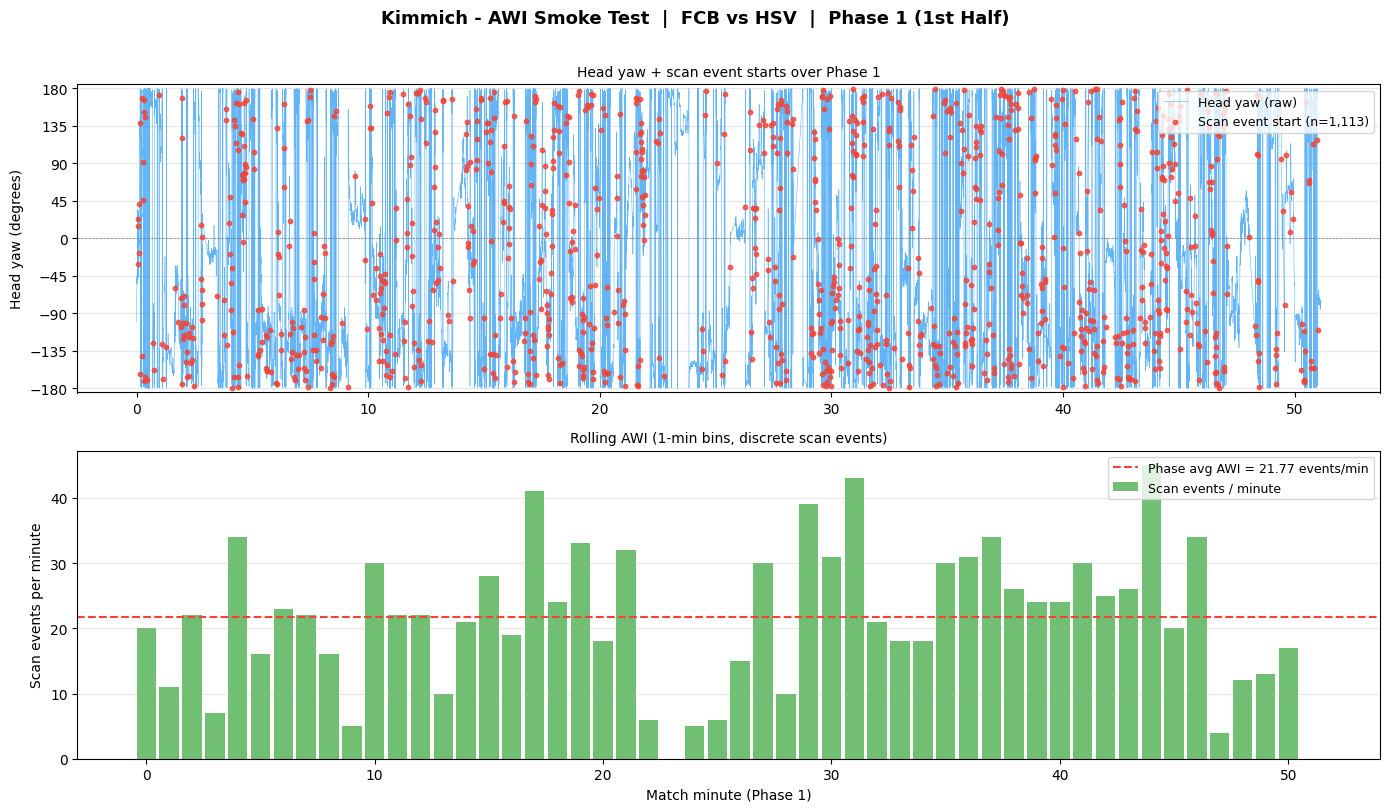

[OK] Plot saved as figures/kimmich_awi_smoke_test.png


In [11]:
# Cell 8: Sanity-check visualisation
#
# Two-panel plot:
#   Top: Head yaw time series, scan EVENT STARTS highlighted (leading edges only)
#   Bottom: Rolling AWI - discrete scan events per 1-minute bin (correct metric)
#
# NOTE: The bottom chart now shows EVENTS/min, not frames/min.
#       One 0.5s scan = 1 event, matching the AWI definition.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

scan_df = scan_df.copy()
scan_df["match_minute"] = (scan_df["frame_number"] - PHASE1_START) / FRAMERATE / 60

# Leading edges: frames where is_scan flips False -> True (= one discrete scan event)
is_scan = scan_df["is_scan"]
prev_scan = is_scan.shift(1, fill_value=False)
scan_df["is_leading_edge"] = is_scan & ~prev_scan

# Count leading edges per 1-minute bin
scan_df["minute_bin"] = (scan_df["match_minute"] // 1).astype(int)
rolling_awi = (
    scan_df.groupby("minute_bin")["is_leading_edge"]
    .sum()
    .reset_index()
    .rename(columns={"minute_bin": "minute", "is_leading_edge": "events_in_minute"})
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
fig.suptitle(
    "Kimmich - AWI Smoke Test  |  FCB vs HSV  |  Phase 1 (1st Half)",
    fontsize=13, fontweight="bold", y=1.01,
)

# Panel 1: Head yaw time series
ax1 = axes[0]
ax1.plot(
    scan_df["match_minute"],
    scan_df["head_yaw_deg"],
    lw=0.4, color="#2196F3", alpha=0.7, label="Head yaw (raw)",
)
scan_events = scan_df[scan_df["is_leading_edge"]]
ax1.scatter(
    scan_events["match_minute"],
    scan_events["head_yaw_deg"],
    s=10, color="#F44336", alpha=0.8,
    label=f"Scan event start (n={len(scan_events):,})",
    zorder=3,
)
ax1.set_ylabel("Head yaw (degrees)", fontsize=10)
ax1.set_ylim(-185, 185)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(45))
ax1.axhline(0, color="grey", lw=0.5, ls="--")
ax1.legend(loc="upper right", fontsize=9)
ax1.set_title("Head yaw + scan event starts over Phase 1", fontsize=10)
ax1.grid(axis="y", alpha=0.3)

# Panel 2: Rolling AWI (events per minute, not frames)
ax2 = axes[1]
ax2.bar(
    rolling_awi["minute"],
    rolling_awi["events_in_minute"],
    width=0.85, color="#4CAF50", alpha=0.8, label="Scan events / minute",
)
ax2.axhline(
    awi_result["awi_per_minute"],
    color="#F44336", lw=1.5, ls="--",
    label=f"Phase avg AWI = {awi_result['awi_per_minute']:.2f} events/min",
)
ax2.set_xlabel("Match minute (Phase 1)", fontsize=10)
ax2.set_ylabel("Scan events per minute", fontsize=10)
ax2.set_title("Rolling AWI (1-min bins, discrete scan events)", fontsize=10)
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/kimmich_awi_smoke_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] Plot saved as figures/kimmich_awi_smoke_test.png")


## Batch Pipeline - All Players, All Matches

Runs AWI for every outfield player across both phases for all 5 matches.

- Phase data is loaded from S3 once per phase (~600s per phase)
- All players are extracted in a single pass over each phase DataFrame  
- Results are saved to `results/awi_all_matches.csv`

Run Cell 9a first (FCB-HSV only) to sanity-check before committing to all 5 matches.

In [12]:
# Cell 9a: Batch AWI - FCB-HSV only (sanity check before full run)
#
# Runs all players x both phases for Bayern vs Hamburg.
# Expect ~2 rows per outfield player (Phase 1 + Phase 2).
# ~25 players x 2 phases = ~50 rows total.
# Time: ~20 min (two S3 phase downloads).

import os, time, importlib
import src.batch_pipeline as bp
importlib.reload(bp)
from src.batch_pipeline import run_match_awi, MATCH_CONFIGS

os.makedirs("results", exist_ok=True)

fcb_hsv_config = next(mc for mc in MATCH_CONFIGS if mc["match_id"] == "FCB-HSV")

print(f"Running batch AWI for {fcb_hsv_config['label']}...")
t0 = time.time()
CHECKPOINT = "results/awi_fcb_hsv.csv"
fcb_hsv_df = run_match_awi(s3_client, s3fs, BUCKET, CHALLENGE_PREFIX, fcb_hsv_config,
                           checkpoint_path=CHECKPOINT)
print(f"\nDone in {time.time()-t0:.0f}s")

# Save
out_path = CHECKPOINT
print(f"Saved {len(fcb_hsv_df)} rows to {out_path}")
print()

# Summary by position
print("AWI summary by position (Phase 1 only):")
ph1 = fcb_hsv_df[fcb_hsv_df["phase_label"].str.contains("1")]
print(
    ph1.groupby("position")[["awi_per_minute", "coverage_pct"]]
    .mean()
    .round(2)
    .sort_values("awi_per_minute", ascending=False)
    .to_string()
)
print()
print("Top 10 players by AWI (Phase 1):")
print(
    ph1.sort_values("awi_per_minute", ascending=False)
    [["name", "position", "jersey", "awi_per_minute", "coverage_pct"]]
    .head(10)
    .to_string(index=False)
)

Running batch AWI for FC Bayern Muenchen vs Hamburger SV...
  [FCB-HSV] 40 players, 2 phases
  [FCB-HSV] Phase 1 (1st half): frames 3,330,943 – 3,484,329 ... 103s
  [FCB-HSV] Phase 1st half done — 40 rows saved to checkpoint.
  [FCB-HSV] Phase 2 (2nd half): frames 3,536,417 – 3,678,119 ... 105s
  [FCB-HSV] Phase 2nd half done — 40 rows saved to checkpoint.

Done in 209s
Saved 80 rows to results/awi_fcb_hsv.csv

AWI summary by position (Phase 1 only):
          awi_per_minute  coverage_pct
position                              
ZO                 20.36          0.99
DML                17.92          0.99
IVZ                17.76          1.00
DRM                17.35          1.00
DMR                14.10          0.66
OLM                13.83          0.98
IVR                11.24          0.99
IVL                11.08          0.66
DLM                10.78          1.00
RA                 10.67          0.50
RV                  7.76          0.50
ORM                 6.10          0.50

In [13]:
# Cell 9b: Batch AWI - All 5 matches
#
# Checkpointing: already-completed matches are loaded from CSV and skipped,
# so re-running after a token expiry continues where it left off.

import time, os, importlib
import src.batch_pipeline as bp
importlib.reload(bp)
from src.batch_pipeline import run_all_matches, MATCH_CONFIGS

os.makedirs("results", exist_ok=True)
checkpoint = "results/awi_all_matches.csv"

print(f"Running batch AWI for all {len(MATCH_CONFIGS)} matches...")
print("Expected time: ~100 min\n")

t0 = time.time()
all_df = run_all_matches(s3_client, s3fs, BUCKET, CHALLENGE_PREFIX, MATCH_CONFIGS,
                         checkpoint_path=checkpoint)
elapsed = time.time() - t0

all_df.to_csv(checkpoint, index=False)

print(f"\nTotal time: {elapsed/60:.1f} min")
print(f"Total rows : {len(all_df):,}")
print(f"Saved to   : {checkpoint}")
print()
print("Rows per match:")
print(all_df.groupby("match_id").size().to_string())
print()
print("AWI distribution across all matches and players:")
print(all_df["awi_per_minute"].describe().round(2).to_string())


Running batch AWI for all 5 matches...
Expected time: ~100 min


=== FCB-HSV: FC Bayern Muenchen vs Hamburger SV ===
  [FCB-HSV] 40 players, 2 phases
  [FCB-HSV] Phase 1 (1st half): frames 3,330,943 – 3,484,329 ... 97s
  [FCB-HSV] Phase 1st half done — 40 rows saved to checkpoint.
  [FCB-HSV] Phase 2 (2nd half): frames 3,536,417 – 3,678,119 ... 99s
  [FCB-HSV] Phase 2nd half done — 40 rows saved to checkpoint.
  Done: 80 player-phase rows
  [checkpoint] Saved 80 rows to results/awi_all_matches.csv

=== BVB-VFB: Borussia Dortmund vs VfB Stuttgart ===
  [BVB-VFB] 40 players, 2 phases
  [BVB-VFB] Phase 1 (1st half): frames 2,790,134 – 2,935,531 ... 93s
  [BVB-VFB] Phase 1st half done — 40 rows saved to checkpoint.
  [BVB-VFB] Phase 2 (2nd half): frames 2,984,098 – 3,141,386 ... 97s
  [BVB-VFB] Phase 2nd half done — 40 rows saved to checkpoint.
  Done: 80 player-phase rows
  [checkpoint] Saved 160 rows to results/awi_all_matches.csv

=== SGE-FCB: Eintracht Frankfurt vs FC Bayern Muenchen =